# Figure 7 — Shorkie accurately predicts cis-eQTL variant effects (reproduction)

Reproduces **main-text Figure 7** (cis-eQTL variant-effect benchmark) panel-for-panel against
the published PDF (`paper/Figures/Figure_7.pdf`). This notebook delegates to the deep-recheck
builders in `recheck/`; each cell regenerates a panel group and the final cell rebuilds the
verdict table (`reproduced/verify_fig07.csv`).

**Deep-recheck correction.** Panel **G (Renganaath)** plots **Shorkie 0.618/0.629** — the top
model, beating DREAM (≈0.59), consistent with the body text. It is scored on the 142-variant
`viz_new/results_subset_tss/` set (the "142 causal core-promoter variants"), not the full
395-variant `results/` set. See `recheck/DISCREPANCIES.md`.

In [1]:
import sys, importlib
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

REPRO = Path.cwd()
if REPRO.name != 'figure_07':
    REPRO = REPRO / 'reproduction' / 'figure_07'
RD = REPRO / 'reproduced'
sys.path.insert(0, str(REPRO / 'recheck'))
sys.path.insert(0, str(REPRO.parent))   # reproduction/  (for common.compare)

def run(mod):
    m = importlib.import_module(mod)
    importlib.reload(m)
    m.main()
    return m

## Panels A/B — eQTL locus coverage (OMA1, LAP3): Ref/Alt prediction + ground truth + gene track

saved /scratch4/ssalzbe1/khchao/shorkie-paper/reproduction/figure_07/reproduced/Figure_7A_reproduced.png
  OMA1: logSED=-0.2198  R(ref,obs)=0.965  R(alt,obs)=0.971  genes=['OMA1', 'TGL4', 'PRP16', 'TVP38']


saved /scratch4/ssalzbe1/khchao/shorkie-paper/reproduction/figure_07/reproduced/Figure_7B_reproduced.png
  LAP3: logSED=+0.2344  R(ref,obs)=0.996  R(alt,obs)=0.997  genes=['LAP3', 'KEX2', 'NAR1']
saved /scratch4/ssalzbe1/khchao/shorkie-paper/reproduction/figure_07/recheck/fig7AB_logsed.csv


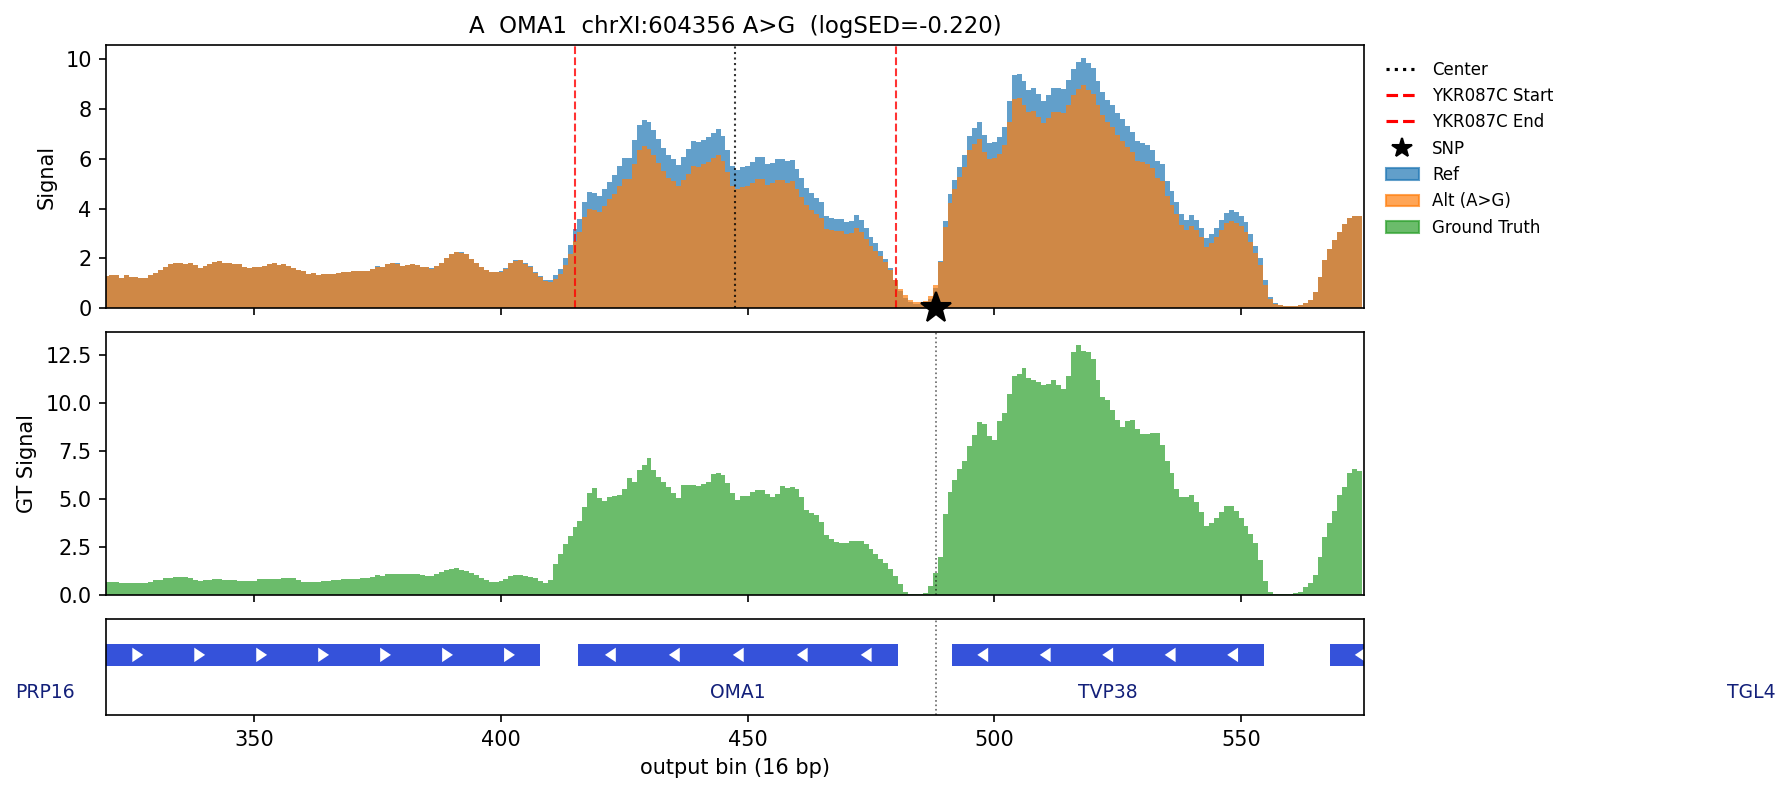

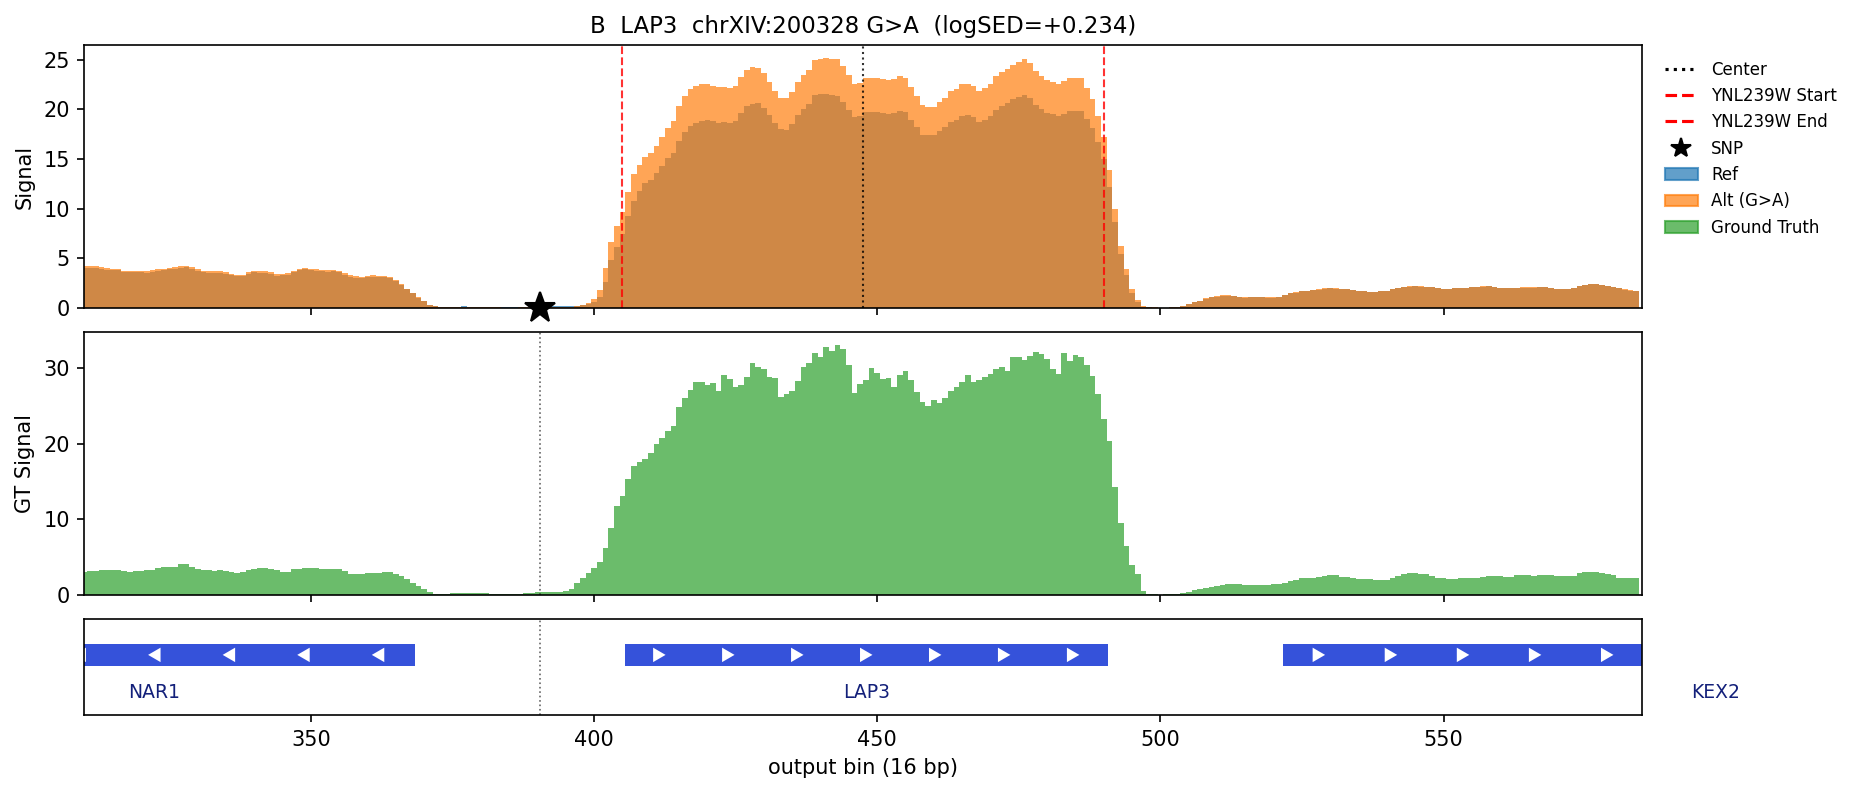

In [2]:
run('build_7AB_coverage')
display(Image(str(RD / 'Figure_7A_reproduced.png')))
display(Image(str(RD / 'Figure_7B_reproduced.png')))

## Panels C/D — logSED computation schematic + matched negative-control generation

saved /scratch4/ssalzbe1/khchao/shorkie-paper/reproduction/figure_07/reproduced/Figure_7C_reproduced.png


saved /scratch4/ssalzbe1/khchao/shorkie-paper/reproduction/figure_07/reproduced/Figure_7D_reproduced.png


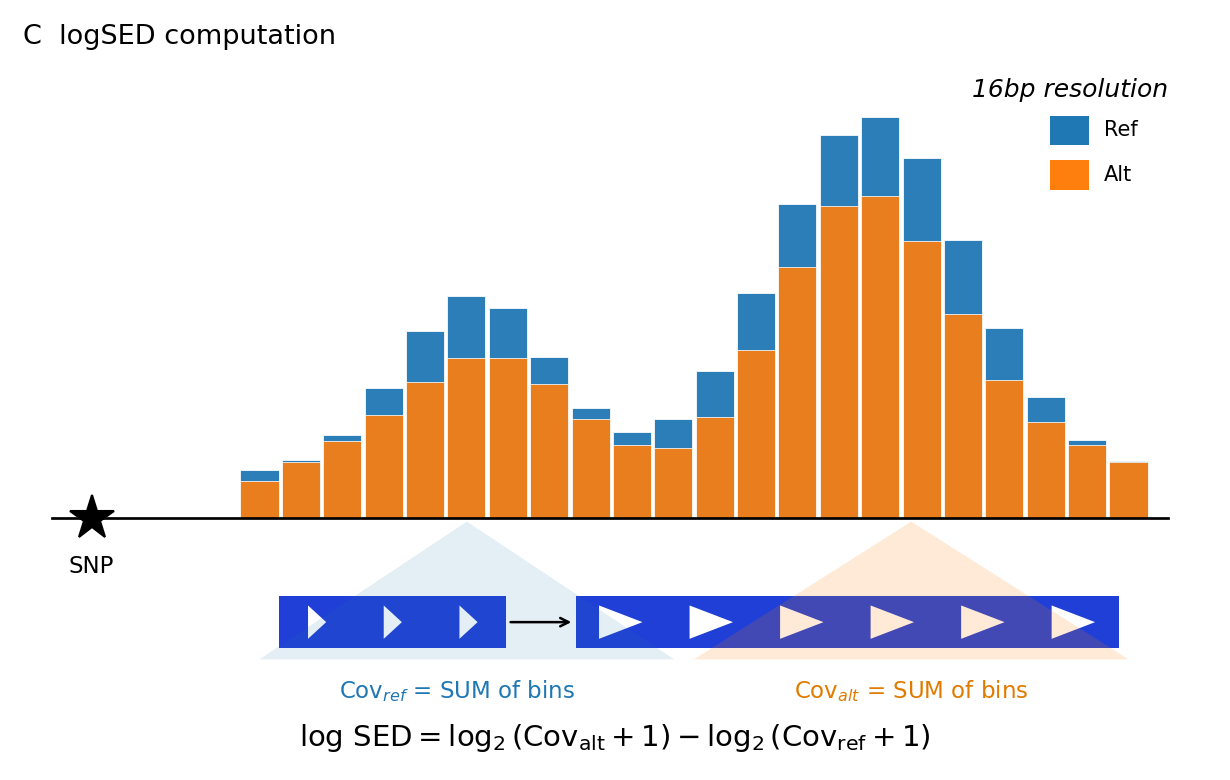

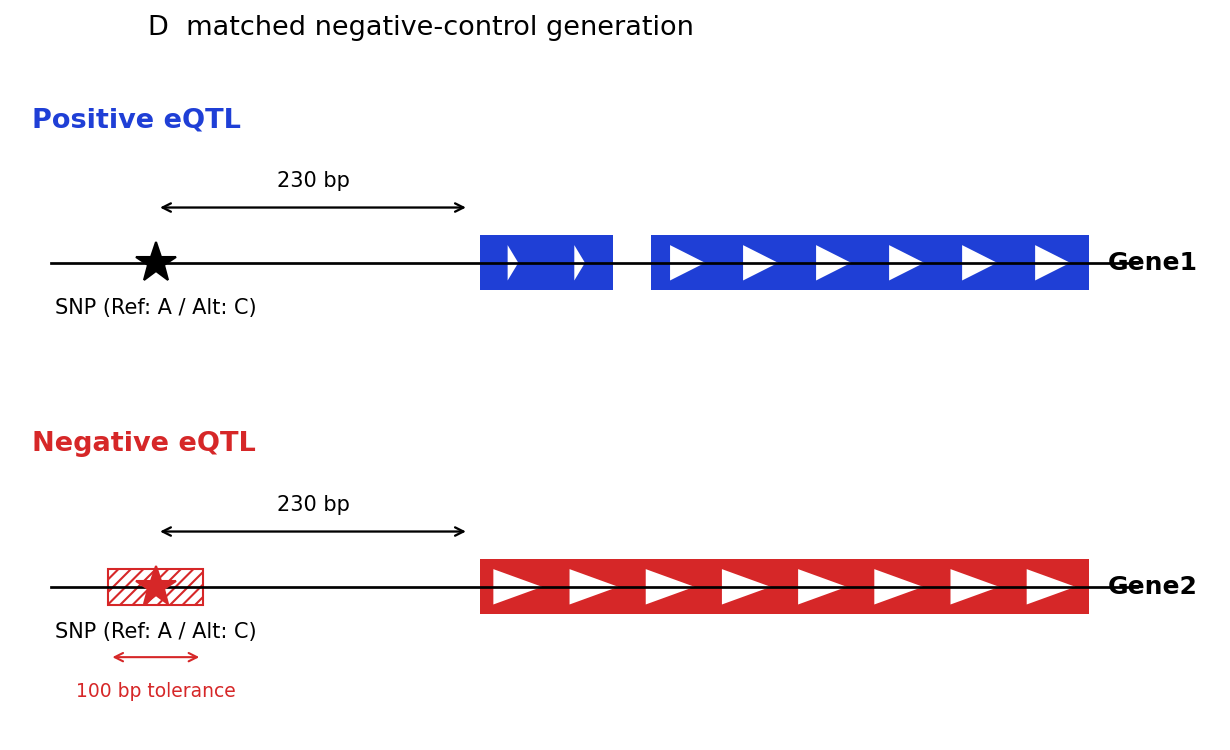

In [3]:
run('build_7CD_schematic')
display(Image(str(RD / 'Figure_7C_reproduced.png')))
display(Image(str(RD / 'Figure_7D_reproduced.png')))

## Panels E/F/G — ensemble ROC & PR (Caudal / Kita / Renganaath)
PR (top row) and ROC (bottom row); 6 models. Renganaath (G) uses the 142-variant subset.

[E caudal_etal] n_pos per model = {'Shorkie': 1712, 'Shorkie_LM': 1818, 'Shorkie_Random_Init': 1711, 'DREAM-Atten': 1818, 'DREAM-CNN': 1818, 'DREAM-RNN': 1818}


[F kita_etal] n_pos per model = {'Shorkie': 655, 'Shorkie_LM': 655, 'Shorkie_Random_Init': 655, 'DREAM-Atten': 655, 'DREAM-CNN': 655, 'DREAM-RNN': 655}


[G Renganaath_etal] n_pos per model = {'Shorkie': 142, 'Shorkie_LM': 142, 'Shorkie_Random_Init': 142, 'DREAM-Atten': 399, 'DREAM-CNN': 399, 'DREAM-RNN': 399}


saved /scratch4/ssalzbe1/khchao/shorkie-paper/reproduction/figure_07/reproduced/Figure_7EFG_reproduced.png
saved /scratch4/ssalzbe1/khchao/shorkie-paper/reproduction/figure_07/recheck/fig7EFG_auc.csv
  E caudal_etal      ROC: Atten=0.526/0.526  CNN=0.529/0.529  RNN=0.524/0.525  Shorkie=0.564/0.564  LM=0.513/0.513  Init=0.541/0.541
  E caudal_etal      PR: Atten=0.536/0.536  CNN=0.537/0.537  RNN=0.538/0.538  Shorkie=0.585/0.585  LM=0.532/0.532  Init=0.551/0.551
  F kita_etal        ROC: Atten=0.534/0.534  CNN=0.539/0.539  RNN=0.532/0.533  Shorkie=0.650/0.650  LM=0.523/0.523  Init=0.641/0.641
  F kita_etal        PR: Atten=0.568/0.568  CNN=0.567/0.567  RNN=0.564/0.564  Shorkie=0.643/0.643  LM=0.555/0.555  Init=0.614/0.614
  G Renganaath_etal  ROC: Atten=0.582/0.585  CNN=0.593/0.596  RNN=0.585/0.590  Shorkie=0.615/0.618  LM=0.471/0.474  Init=0.426/0.424
  G Renganaath_etal  PR: Atten=0.585/0.588  CNN=0.589/0.593  RNN=0.589/0.596  Shorkie=0.624/0.629  LM=0.486/0.492  Init=0.446/0.447
max |

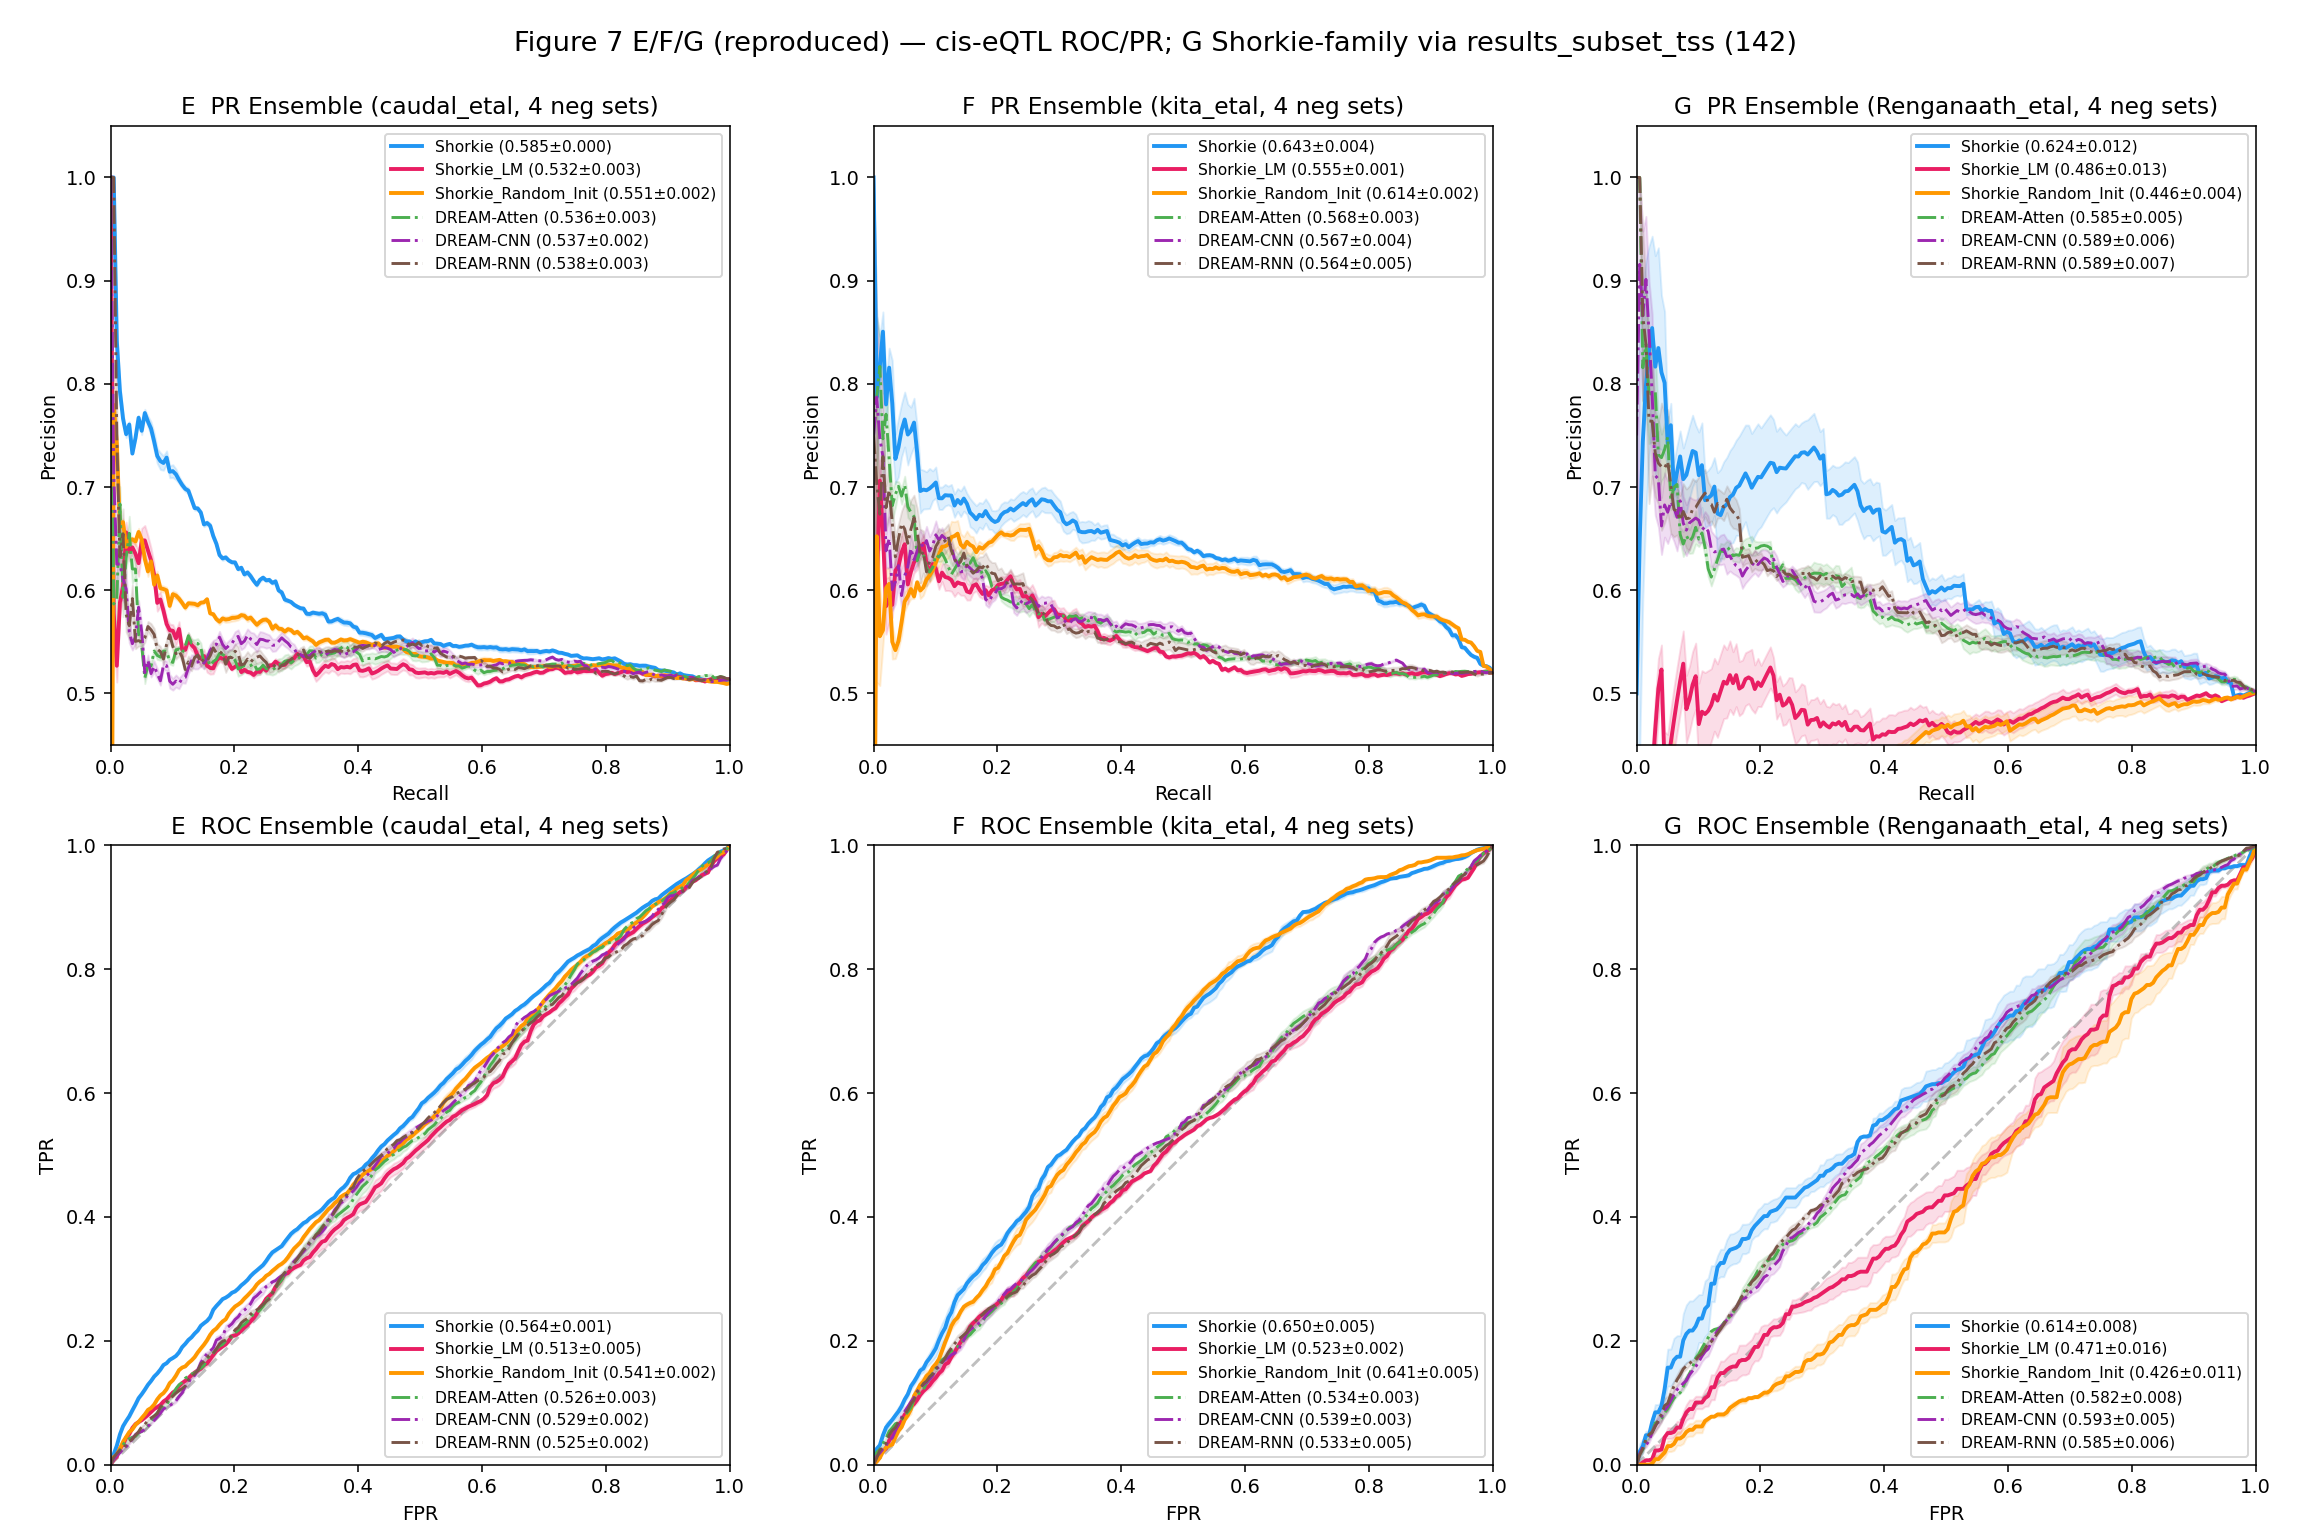

,panel,dataset,model,metric,auc_mean,auc_sem,published,delta
0,E,caudal_etal,Shorkie,PR,0.5846,0.0005,0.585,-0.0004
1,E,caudal_etal,Shorkie_LM,PR,0.5319,0.0030,0.532,-0.0001
2,E,caudal_etal,Shorkie_Random_Init,PR,0.5512,0.0015,0.551,0.0002
3,E,caudal_etal,DREAM-Atten,PR,0.5361,0.0028,0.536,0.0001
4,E,caudal_etal,DREAM-CNN,PR,0.5371,0.0022,0.537,0.0001
5,E,caudal_etal,DREAM-RNN,PR,0.5380,0.0027,0.538,0.0000
6,E,caudal_etal,Shorkie,ROC,0.5639,0.0013,0.564,-0.0001
7,E,caudal_etal,Shorkie_LM,ROC,0.5126,0.0046,0.513,-0.0004
8,E,caudal_etal,Shorkie_Random_Init,ROC,0.5411,0.0018,0.541,0.0001
9,E,caudal_etal,DREAM-Atten,ROC,0.5257,0.0033,0.526,-0.0003


In [4]:
run('build_7EFG_roc_pr')
display(Image(str(RD / 'Figure_7EFG_reproduced.png')))
display(pd.read_csv(REPRO / 'recheck' / 'fig7EFG_auc.csv'))

## Panels H/I — AUPRC by TSS-distance bin (Shorkie vs DREAM)

[H caudal_etal] frac bins Shorkie>=DREAM-RNN AUPRC = 1.000 (n_bins=5)


[I kita_etal] frac bins Shorkie>=DREAM-RNN AUPRC = 1.000 (n_bins=4)


saved /scratch4/ssalzbe1/khchao/shorkie-paper/reproduction/figure_07/reproduced/Figure_7HI_reproduced.png
saved /scratch4/ssalzbe1/khchao/shorkie-paper/reproduction/figure_07/recheck/fig7HI_auprc.csv


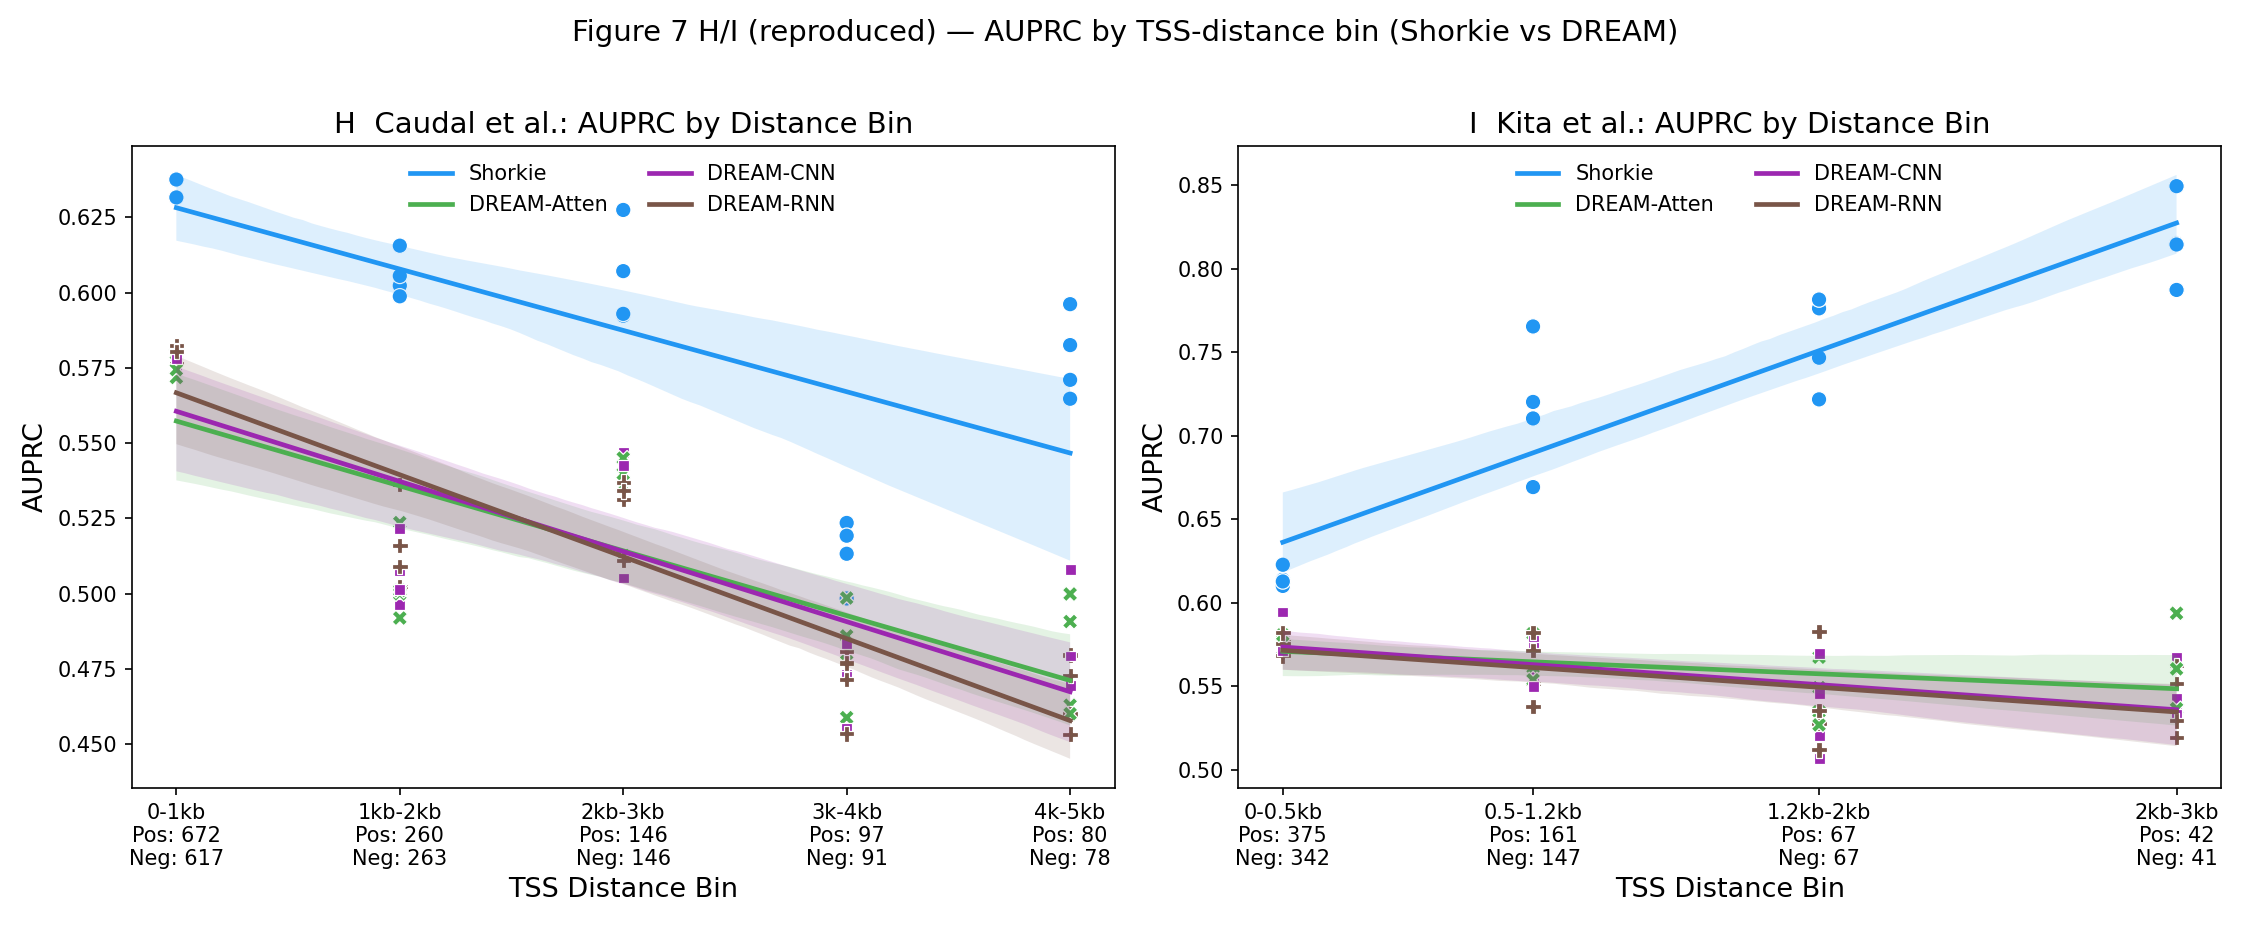

In [5]:
run('build_7HI_distance')
display(Image(str(RD / 'Figure_7HI_reproduced.png')))

## Panels J–O — eQTL-SNP ISM saliency (six loci)
Shorkie ISM REF/ALT logos recomputed from the released ISM cache; DREAM-RNN ISM from cached
deltas (4/6 loci on disk); Ref DB motifs from the project motif DB; coverage from observed RNA-seq.

saved /scratch4/ssalzbe1/khchao/shorkie-paper/reproduction/figure_07/reproduced/Figure_7JO_reproduced.png
saved /scratch4/ssalzbe1/khchao/shorkie-paper/reproduction/figure_07/recheck/fig7JO_logsed.csv
[verify] 18/18 PASS -> /scratch4/ssalzbe1/khchao/shorkie-paper/reproduction/figure_07/recheck/verify_fig7JO.csv
Figure 7 J-O deep-verify: 18/18 PASS  (region/SNP/ref/alt/motif confirmed for all 6 loci)
  J YER080W chrV:321,861-321,941 G>T (pub G>T) OK  motif=Polyadenylation efficiency elements  dream_on_disk=True  maxISM=0.01267
  K YLR036C chrXII:221,336-221,416 A>G (pub A>G) OK  motif=Polyadenylation efficiency elements  dream_on_disk=False  maxISM=0.01579
  L YKL078W chrXI:288,734-288,814 G>A (pub G>A) OK  motif=PAC motif (Dot6)  dream_on_disk=True  maxISM=0.01044
  M YKR087C chrXI:604,316-604,396 A>G (pub A>G) OK  motif=Reb1.1  dream_on_disk=True  maxISM=0.01722
  N YNL239W chrXIV:200,288-200,368 G>A (pub G>A) OK  motif=Reb1.1  dream_on_disk=True  maxISM=0.01359
  O YGR046W chrVII:584

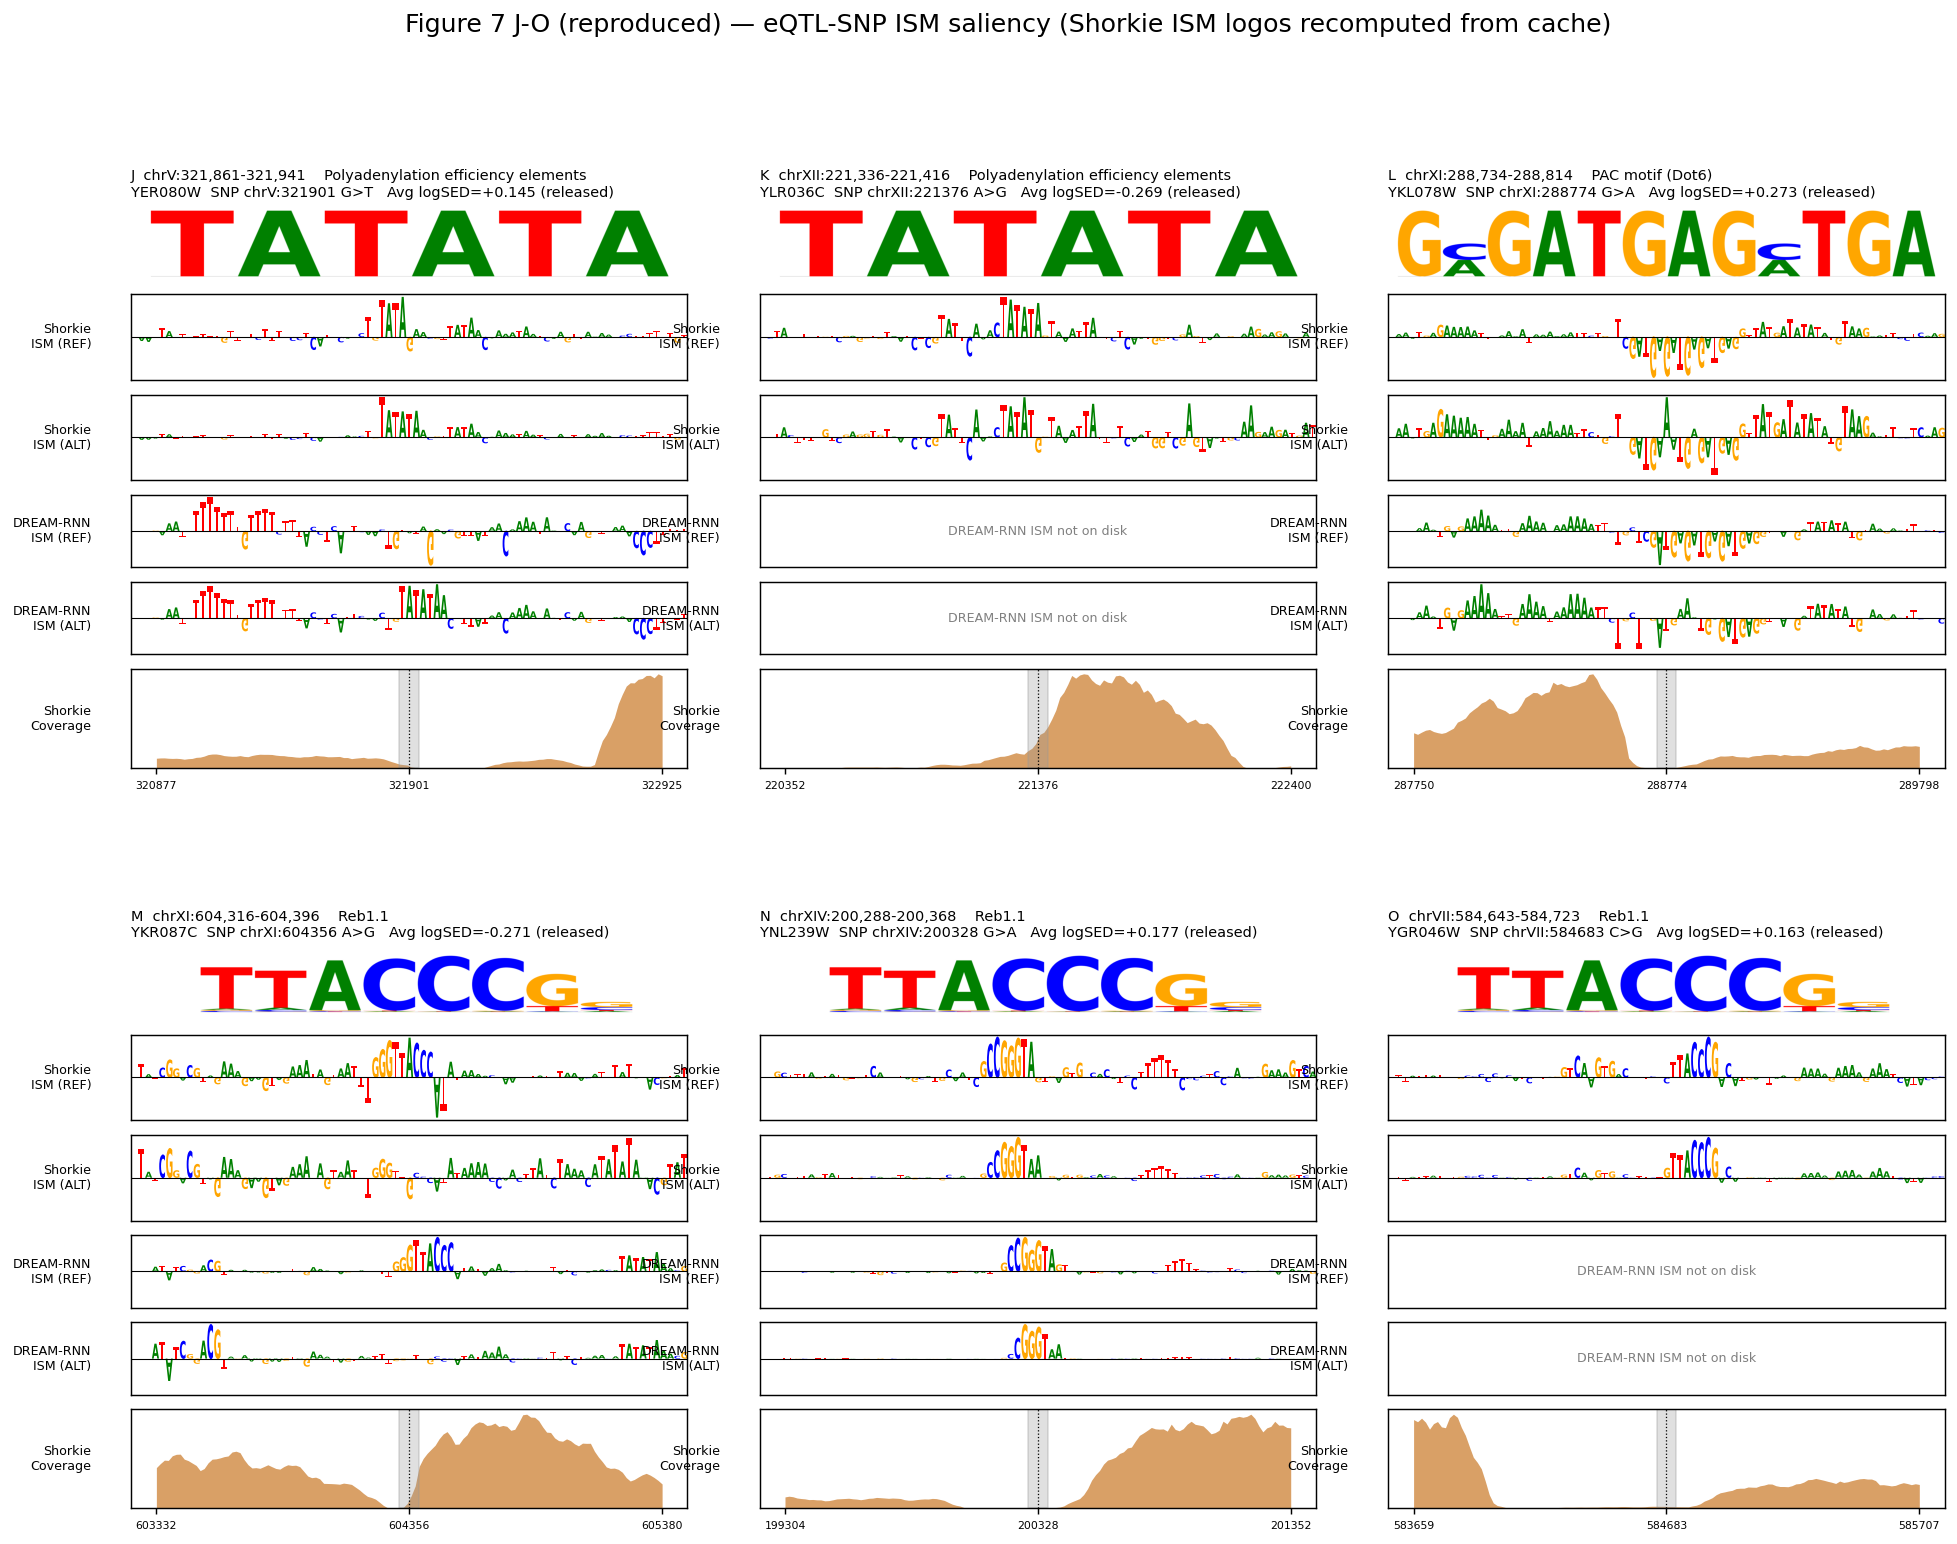

In [6]:
run('build_7JO_ism')
display(Image(str(RD / 'Figure_7JO_reproduced.png')))

## Verification — rebuild `verify_fig07.csv` against the published figure

In [7]:
run('build_verify_fig07')
v = pd.read_csv(RD / 'verify_fig07.csv')
print('PASS', (v.verdict=='PASS').sum(), '/', len(v))
display(v)

[verify] 66/66 PASS -> /scratch4/ssalzbe1/khchao/shorkie-paper/reproduction/figure_07/reproduced/verify_fig07.csv
[verify] 66/66 PASS -> /scratch4/ssalzbe1/khchao/shorkie-paper/reproduction/figure_07/recheck/recheck_checks_fig07.csv

Figure 7 verify: 66/66 PASS
PASS 66 / 66


,panel,metric,reported,reproduced,delta,rtol,atol,verdict
0,E,PR[Shorkie]==paperFig [Caudal et al.],0.585,0.58500,0.00000,0.02,0.01,PASS
1,E,PR[Shorkie_LM]==paperFig [Caudal et al.],0.532,0.53200,0.00000,0.02,0.01,PASS
2,E,PR[Shorkie_Random_Init]==paperFig [Caudal et al.],0.551,0.55100,0.00000,0.02,0.01,PASS
3,E,PR[DREAM-Atten]==paperFig [Caudal et al.],0.536,0.53600,0.00000,0.02,0.01,PASS
4,E,PR[DREAM-CNN]==paperFig [Caudal et al.],0.537,0.53700,0.00000,0.02,0.01,PASS
...,...,...,...,...,...,...,...,...
61,K,Shorkie ISM saliency recomputed [YLR036C],0.000,0.01579,0.01579,0.02,0.00,PASS
62,L,Shorkie ISM saliency recomputed [YKL078W],0.000,0.01044,0.01044,0.02,0.00,PASS
63,M,Shorkie ISM saliency recomputed [YKR087C],0.000,0.01722,0.01722,0.02,0.00,PASS
64,N,Shorkie ISM saliency recomputed [YNL239W],0.000,0.01359,0.01359,0.02,0.00,PASS
